         x1        x2  etiqueta
0 -0.008864  0.113353         0
1  0.242456 -0.075897         0
2 -0.014196 -0.070382         0
3 -0.165579 -0.143002         0
4  0.202125  0.327485         0


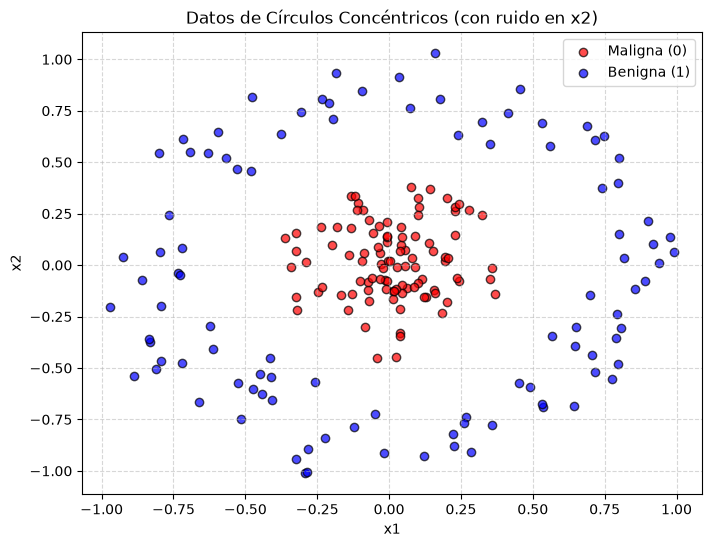

In [1]:
import numpy as np
import pandas as pd

# 1. Configurar semilla para reproducibilidad
np.random.seed(42)

# 2. Definir parámetros
n_samples_per_class = 100  # 100 para malignas (0) y 100 para benignas (1)
n_total = n_samples_per_class * 2

# 3. Generar círculos concéntricos
# Clase 0: Círculo interno (Malignas)
theta_0 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_0 = np.random.uniform(0, 0.4, n_samples_per_class)
x1_0 = r_0 * np.cos(theta_0)
x2_0 = r_0 * np.sin(theta_0)
y_0 = np.zeros(n_samples_per_class)

# Clase 1: Círculo externo (Benignas)
theta_1 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_1 = np.random.uniform(0.7, 1.0, n_samples_per_class)
x1_1 = r_1 * np.cos(theta_1)
x2_1 = r_1 * np.sin(theta_1)
y_1 = np.ones(n_samples_per_class)

# 4. Combinar los datos
x1 = np.concatenate([x1_0, x1_1])
x2 = np.concatenate([x2_0, x2_1])
etiqueta = np.concatenate([y_0, y_1])

# 5. Agregar ruido al valor de x2
ruido = np.random.normal(0, 0.08, n_total)
x2 = x2 + ruido

# 6. Crear un DataFrame de Pandas
df_celulas = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'etiqueta': etiqueta.astype(int)
})

# Mostrar las primeras 5 filas del dataset
df_celulas.head()

## Red neuronal MLP optimizada
Esta red neuronal utiliza un **perceptrón multicapa (MLP)** para aprender la frontera no lineal de los círculos concéntricos. El escalado se ajusta únicamente con los datos de entrenamiento y la búsqueda de hiperparámetros se realiza mediante validación cruzada estratificada.

Modelo guardado en: modelo_mlp_circulos.joblib
Mejores hiperparámetros:
{'red__alpha': 0.0001, 'red__hidden_layer_sizes': (32, 16), 'red__learning_rate_init': 0.009000000000000001}
F1 medio en validación cruzada: 98.22%
Iteraciones realizadas por la red: 54

Métricas en el conjunto de prueba:
Accuracy : 95.00%
Precision: 90.91%
Recall   : 100.00%
F1       : 95.24%

Reporte detallado (%):


,Precisión (%),Recall (%),F1 (%),Cantidad
Maligna (0),100.00%,90.00%,94.74%,20
Benigna (1),90.91%,100.00%,95.24%,20
accuracy,95.00%,95.00%,95.00%,1
macro avg,95.45%,95.00%,94.99%,40
weighted avg,95.45%,95.00%,94.99%,40


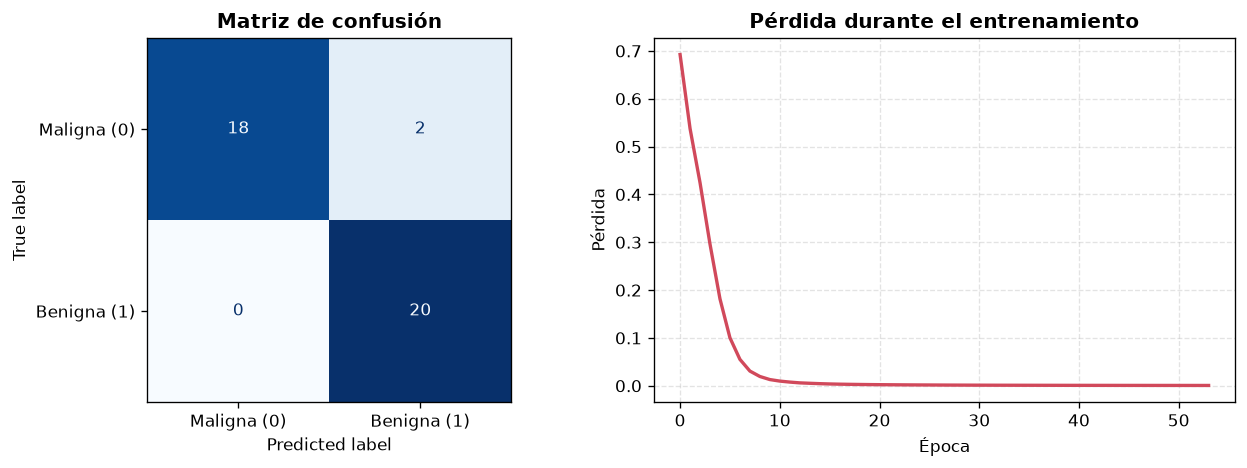

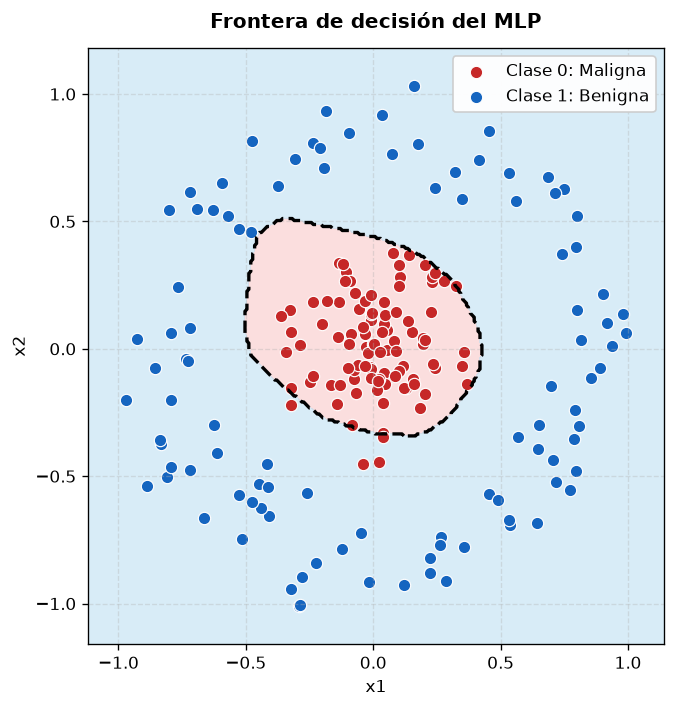

In [13]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np
import joblib

# Parámetros editables del entrenamiento
epocas_maximas = 3000
tasa_aprendizaje = 0.003
tasas_a_probar = [tasa_aprendizaje / 3, tasa_aprendizaje, tasa_aprendizaje * 3]
ruta_modelo = 'modelo_mlp_circulos.joblib'

# Separar características y etiqueta
X = df_celulas[['x1', 'x2']]
y = df_celulas['etiqueta']

# El conjunto de prueba no participa en el escalado ni en la búsqueda
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
 )

# El pipeline evita fuga de información durante la validación cruzada
pipeline_mlp = Pipeline([
    ('escalador', StandardScaler()),
    ('red', MLPClassifier(
        solver='adam',
        activation='relu',
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=50,
        tol=1e-4,
        batch_size=16,
        max_iter=epocas_maximas,
        random_state=42
    ))
])

parametros = {
    'red__hidden_layer_sizes': [(8,), (16,), (16, 8), (32, 16)],
    'red__alpha': [1e-4, 1e-3, 1e-2],
    'red__learning_rate_init': tasas_a_probar
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
busqueda = GridSearchCV(
    estimator=pipeline_mlp,
    param_grid=parametros,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    refit=True
 )
busqueda.fit(X_train, y_train)

modelo_mlp = busqueda.best_estimator_
predicciones = modelo_mlp.predict(X_test)

# Guardar el pipeline completo: escalador + red neuronal + parámetros
joblib.dump(modelo_mlp, ruta_modelo)
print(f'Modelo guardado en: {ruta_modelo}')
print('Mejores hiperparámetros:')
print(busqueda.best_params_)
print(f'F1 medio en validación cruzada: {busqueda.best_score_ * 100:.2f}%')
print(f'Iteraciones realizadas por la red: {modelo_mlp.named_steps["red"].n_iter_}')
print('\nMétricas en el conjunto de prueba:')
print(f'Accuracy : {accuracy_score(y_test, predicciones) * 100:.2f}%')
print(f'Precision: {precision_score(y_test, predicciones) * 100:.2f}%')
print(f'Recall   : {recall_score(y_test, predicciones) * 100:.2f}%')
print(f'F1       : {f1_score(y_test, predicciones) * 100:.2f}%')
print('\nReporte detallado (%):')
reporte = pd.DataFrame(classification_report(
    y_test, predicciones, target_names=['Maligna (0)', 'Benigna (1)'],
    output_dict=True
 )).T
reporte[['precision', 'recall', 'f1-score']] *= 100
reporte = reporte.rename(columns={
    'precision': 'Precisión (%)',
    'recall': 'Recall (%)',
    'f1-score': 'F1 (%)',
    'support': 'Cantidad'
})
display(reporte.style.format({
    'Precisión (%)': '{:.2f}%',
    'Recall (%)': '{:.2f}%',
    'F1 (%)': '{:.2f}%',
    'Cantidad': '{:.0f}'
}, na_rep='-'))

# Gráficas esenciales: rendimiento y aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=120)
ConfusionMatrixDisplay.from_predictions(
    y_test, predicciones, display_labels=['Maligna (0)', 'Benigna (1)'],
    cmap='Blues', colorbar=False, ax=axes[0]
 )
axes[0].set_title('Matriz de confusión', weight='bold')

red = modelo_mlp.named_steps['red']
axes[1].plot(red.loss_curve_, color='#D1495B', linewidth=2)
axes[1].set_title('Pérdida durante el entrenamiento', weight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Pérdida')
axes[1].grid(True, linestyle='--', alpha=0.35)
fig.tight_layout()
plt.show()

# Frontera de decisión simple: solo las dos clases y sus datos
margen = 0.15
x1_grid = np.linspace(X['x1'].min() - margen, X['x1'].max() + margen, 300)
x2_grid = np.linspace(X['x2'].min() - margen, X['x2'].max() + margen, 300)
xx, yy = np.meshgrid(x1_grid, x2_grid)
grid = pd.DataFrame({'x1': xx.ravel(), 'x2': yy.ravel()})
clases_grid = modelo_mlp.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6), dpi=120)
ax.contourf(xx, yy, clases_grid, levels=[-0.5, 0.5, 1.5],
             colors=['#F8C4C4', '#B9DDF2'], alpha=0.55)
ax.contour(xx, yy, clases_grid, levels=[0.5],
            colors='black', linewidths=2, linestyles='--')

ax.scatter(X[y == 0]['x1'], X[y == 0]['x2'],
           color='#C62828', marker='o', s=55, edgecolors='white',
           linewidths=0.7, label='Clase 0: Maligna')
ax.scatter(X[y == 1]['x1'], X[y == 1]['x2'],
           color='#1565C0', marker='o', s=55, edgecolors='white',
           linewidths=0.7, label='Clase 1: Benigna')

ax.set_title('Frontera de decisión del MLP', weight='bold', pad=12)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_xlim(x1_grid.min(), x1_grid.max())
ax.set_ylim(x2_grid.min(), x2_grid.max())
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(loc='upper right', framealpha=0.95)
fig.tight_layout()
plt.show()

In [16]:
# Cargar el modelo en otra sesión sin volver a entrenarlo
modelo_cargado = joblib.load(ruta_modelo)

# Ejemplo de predicción con nuevas observaciones [[x1, x2], ...]
nuevos_datos = pd.DataFrame({
    'x1': [0.10, 0.85],
    'x2': [0.05, 0.10]
})
predicciones_nuevas = modelo_cargado.predict(nuevos_datos)
probabilidades_nuevas = modelo_cargado.predict_proba(nuevos_datos)[:, 1] * 100

resultado = nuevos_datos.copy()
resultado['prediccion'] = predicciones_nuevas
resultado['resultado'] = np.where(
    predicciones_nuevas == 1, 'Benigna', 'Maligna'
 )
resultado['probabilidad_benigna (%)'] = probabilidades_nuevas
display(resultado.style.format({
    'x1': '{:.2f}',
    'x2': '{:.2f}',
    'probabilidad_benigna (%)': '{:.2f}%'
}))

,x1,x2,prediccion,resultado,probabilidad_benigna (%)
0,0.10,0.05,0,Maligna,29.71%
1,0.85,0.10,1,Benigna,82.79%


In [17]:
# Tabla final de resultados obtenidos
tabla_metricas = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precisión', 'Recall', 'F1', 'F1 validación cruzada'],
    'Porcentaje': [
        accuracy_score(y_test, predicciones) * 100,
        precision_score(y_test, predicciones) * 100,
        recall_score(y_test, predicciones) * 100,
        f1_score(y_test, predicciones) * 100,
        busqueda.best_score_ * 100
    ]
})

tabla_configuracion = pd.DataFrame({
    'Parámetro': [
        'Épocas máximas',
        'Tasa de aprendizaje base',
        'Tasa de aprendizaje elegida',
        'Arquitectura',
        'Regularización alpha',
        'Épocas ejecutadas'
    ],
    'Valor': [
        epocas_maximas,
        tasa_aprendizaje,
        modelo_mlp.named_steps['red'].learning_rate_init,
        modelo_mlp.named_steps['red'].hidden_layer_sizes,
        modelo_mlp.named_steps['red'].alpha,
        modelo_mlp.named_steps['red'].n_iter_
    ]
})

print('RESULTADOS DEL MODELO')
display(tabla_metricas.style.format({'Porcentaje': '{:.2f}%'}))
print('CONFIGURACIÓN SELECCIONADA')
display(tabla_configuracion)

print('PREDICCIONES DE NUEVOS DATOS')
display(resultado.style.format({
    'x1': '{:.2f}',
    'x2': '{:.2f}',
    'probabilidad_benigna (%)': '{:.2f}%'
}))

RESULTADOS DEL MODELO


,Métrica,Porcentaje
0,Accuracy,95.00%
1,Precisión,90.91%
2,Recall,100.00%
3,F1,95.24%
4,F1 validación cruzada,98.22%


CONFIGURACIÓN SELECCIONADA


,Parámetro,Valor
0,Épocas máximas,3000
1,Tasa de aprendizaje base,0.003
2,Tasa de aprendizaje elegida,0.009
3,Arquitectura,"(32, 16)"
4,Regularización alpha,0.0001
5,Épocas ejecutadas,54


PREDICCIONES DE NUEVOS DATOS


,x1,x2,prediccion,resultado,probabilidad_benigna (%)
0,0.10,0.05,0,Maligna,29.71%
1,0.85,0.10,1,Benigna,82.79%
